In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Reading**

In [2]:
df = pd.read_csv('Datasets\cumulative.csv')
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   str    
 3   kepler_name        2294 non-null   str    
 4   koi_disposition    9564 non-null   str    
 5   koi_pdisposition   9564 non-null   str    
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 non-null   

In [4]:
df.isnull().sum()       # Missing values

rowid                   0
kepid                   0
kepoi_name              0
kepler_name          7270
koi_disposition         0
koi_pdisposition        0
koi_score            1510
koi_fpflag_nt           0
koi_fpflag_ss           0
koi_fpflag_co           0
koi_fpflag_ec           0
koi_period              0
koi_period_err1       454
koi_period_err2       454
koi_time0bk             0
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_impact            363
koi_impact_err1       454
koi_impact_err2       454
koi_duration            0
koi_duration_err1     454
koi_duration_err2     454
koi_depth             363
koi_depth_err1        454
koi_depth_err2        454
koi_prad              363
koi_prad_err1         363
koi_prad_err2         363
koi_teq               363
koi_teq_err1         9564
koi_teq_err2         9564
koi_insol             321
koi_insol_err1        321
koi_insol_err2        321
koi_model_snr         363
koi_tce_plnt_num      346
koi_tce_delivname     346
koi_steff   

In [5]:
df['koi_disposition'].value_counts()

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

In [6]:
df['koi_pdisposition'].value_counts()

koi_pdisposition
FALSE POSITIVE    5068
CANDIDATE         4496
Name: count, dtype: int64

In [7]:
# The koi_teq_err1 and koi_teq_err2 are empty columns, also the id/label columns aren't useful for analysis.
df = df.drop(columns=['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_teq_err1', 'koi_teq_err2'], errors='ignore')
df.shape

(9564, 44)

In [11]:
skewness = df.skew(numeric_only=True)
skewness.sort_values(ascending=False)

koi_period           96.459326
koi_depth_err1       92.693639
koi_prad             52.118954
koi_insol            49.947777
koi_insol_err1       42.902621
koi_prad_err1        40.588184
koi_impact           23.505943
koi_srad             20.947097
koi_srad_err1        18.630659
koi_time0bk_err1     11.166367
koi_period_err1       8.516557
koi_duration_err1     8.295464
koi_impact_err1       6.341046
koi_duration          5.928765
koi_model_snr         5.307083
koi_depth             5.260652
koi_time0bk           3.682070
koi_tce_plnt_num      3.665103
koi_teq               3.505694
koi_slogg_err1        2.993190
koi_fpflag_ec         2.338618
koi_fpflag_nt         1.595610
koi_fpflag_co         1.540689
koi_fpflag_ss         1.272691
koi_steff_err1        0.763875
koi_steff             0.749782
dec                   0.169174
koi_score             0.056506
ra                   -0.282209
koi_kepmag           -0.796031
koi_slogg_err2       -1.614569
koi_slogg            -3.433093
koi_stef

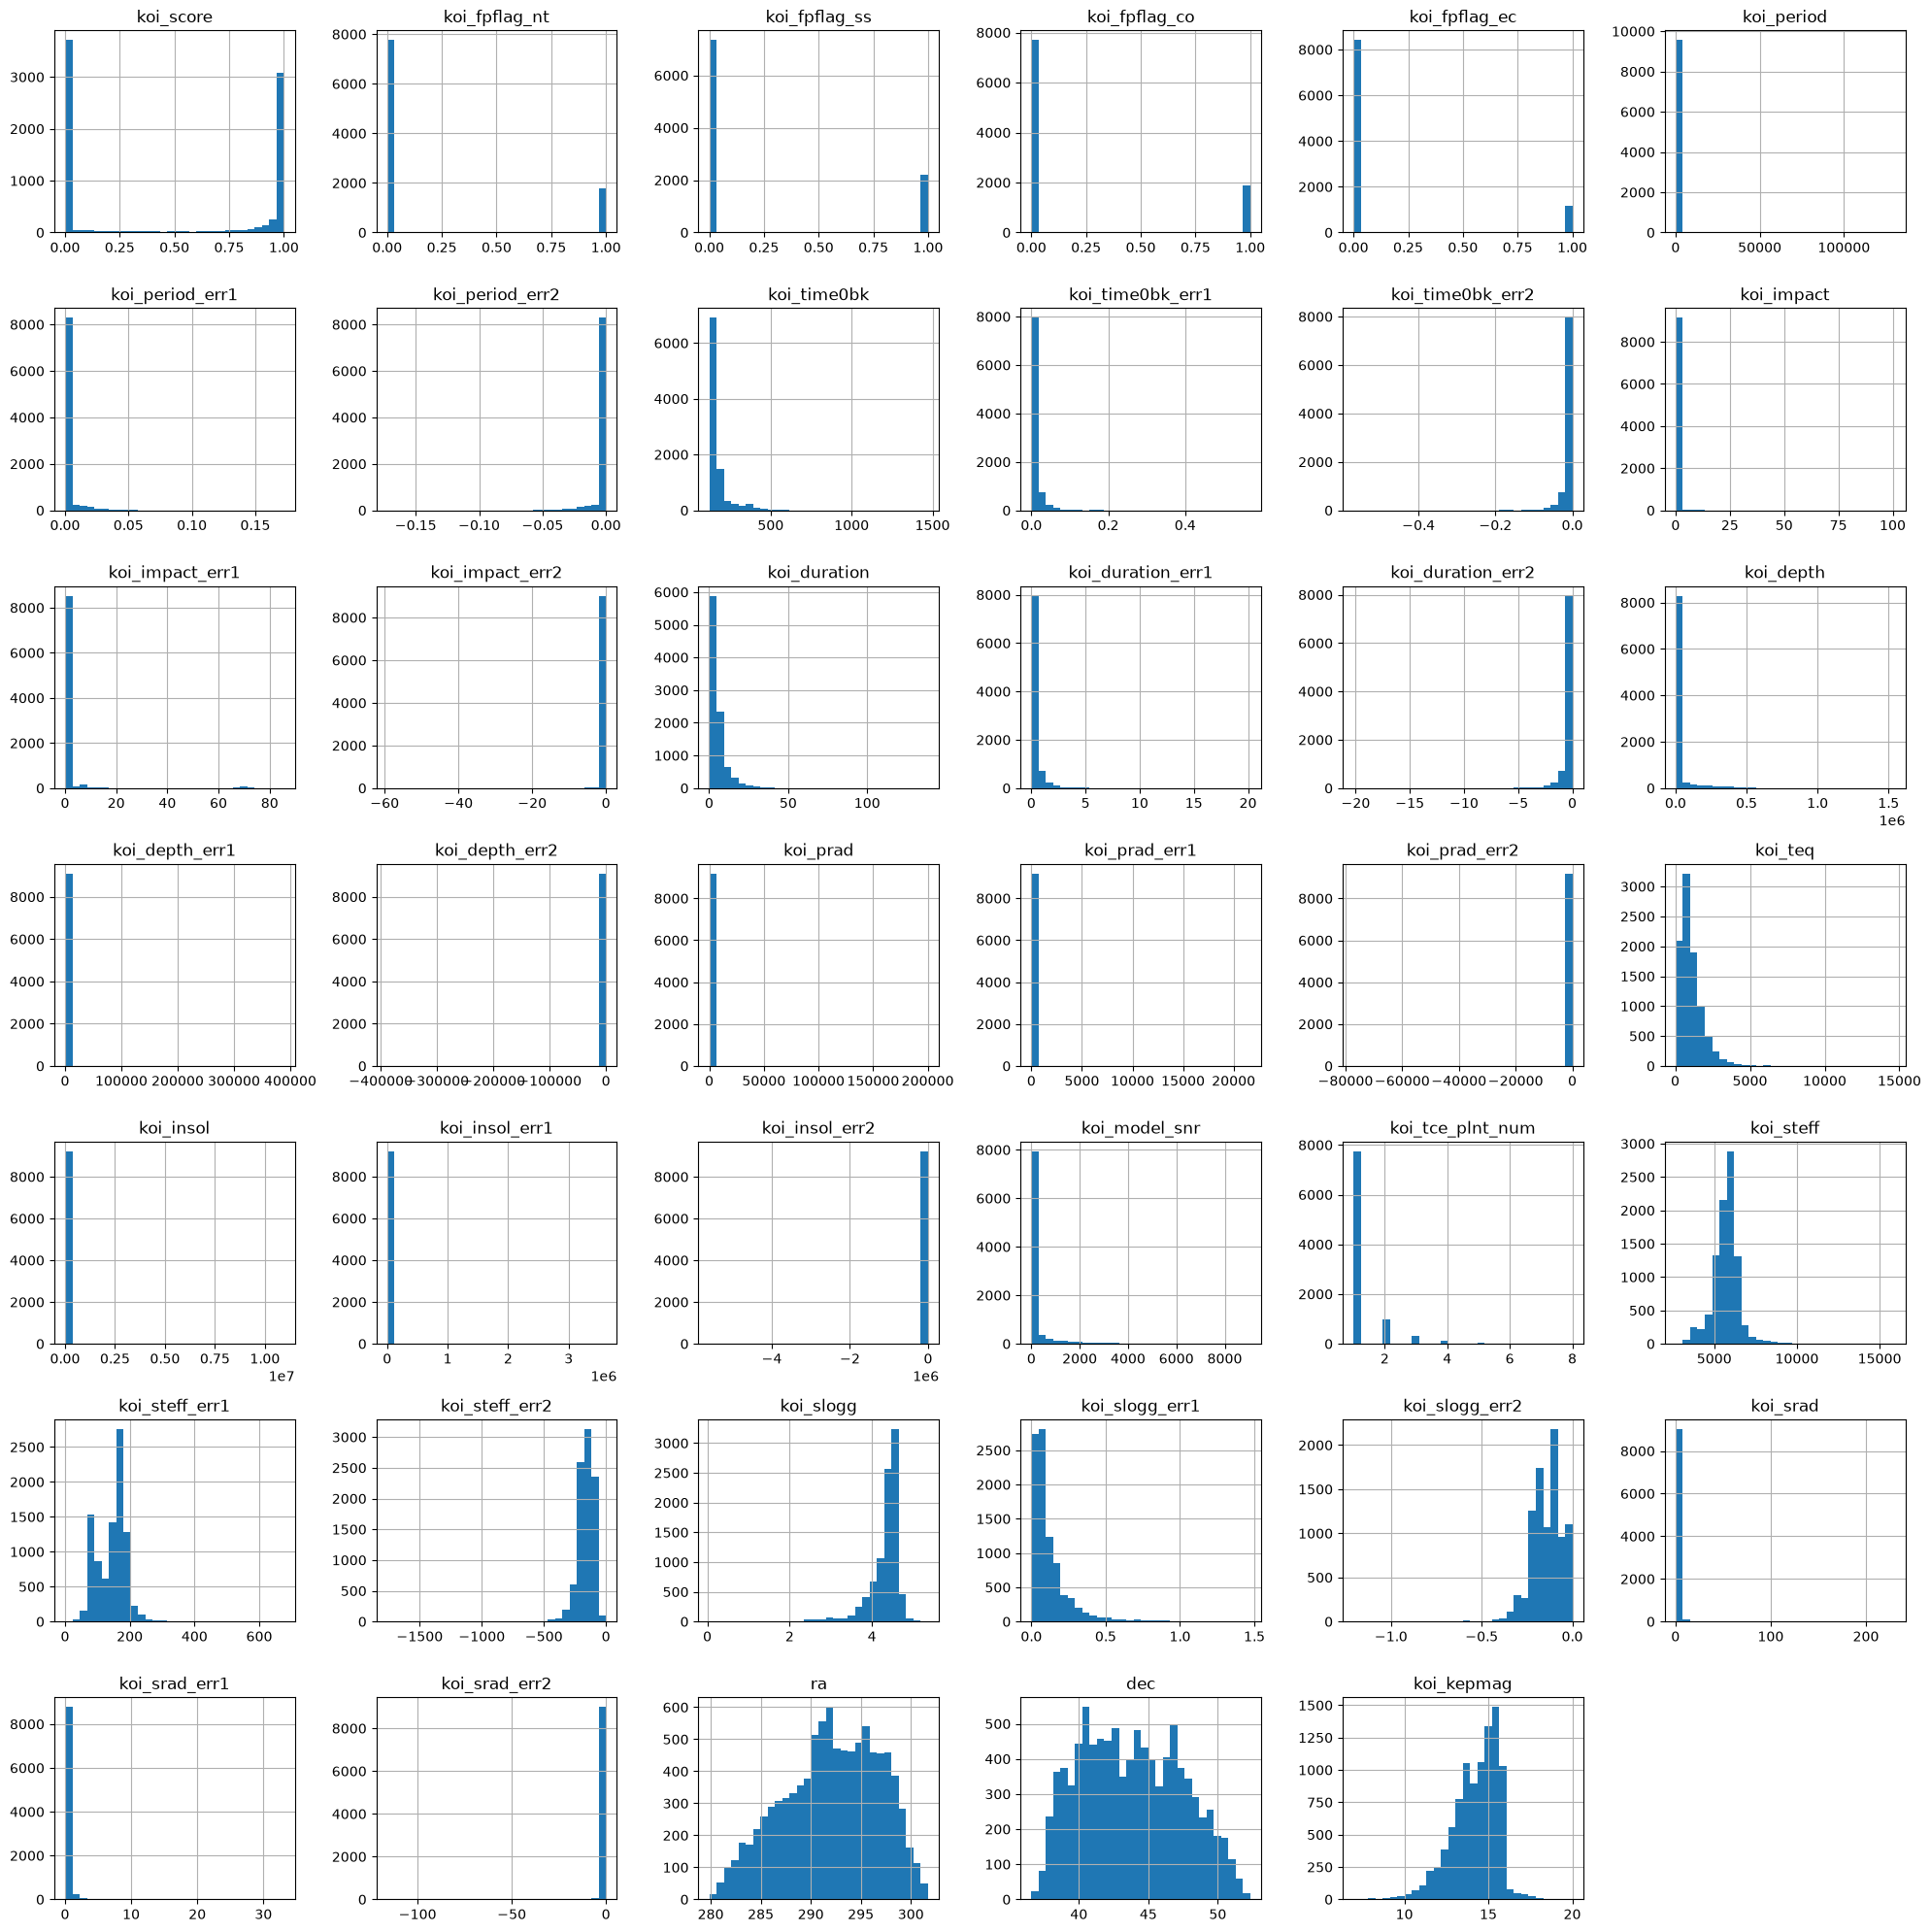

In [15]:
df.hist(figsize=(20, 20), bins=30)

plt.tight_layout()
plt.show()